In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

I0000 00:00:1781095499.595944  125117 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781095499.660927  125117 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781095501.219667  125117 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
_dataset = keras.utils.image_dataset_from_directory(
    '../datasets/cifar10/train', image_size=(32, 32), batch_size=64, shuffle=False, label_mode='int'
)

mean    = tf.zeros(3)
sq_mean = tf.zeros(3)
n_pixels = 0

for images, _ in _dataset:
    images   = tf.cast(images, tf.float32) / 255.0  # [0, 255] -> [0.0, 1.0]
    b, h, w, c = images.shape  # NHWC
    n_pixels += b * h * w
    mean     += tf.reduce_sum(images, axis=[0, 1, 2])  # N, H, W -> (C,)
    sq_mean  += tf.reduce_sum(images ** 2, axis=[0, 1, 2])

mean  /= n_pixels
std    = tf.sqrt(sq_mean / n_pixels - mean ** 2)  # Var(X) = E[X²] - E[X]²

MEAN = tuple(round(float(i), 4) for i in mean)
STD  = tuple(round(float(i), 4) for i in std)

MEAN, STD

Found 50000 files belonging to 10 classes.


I0000 00:00:1781095504.686734  125117 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:1e.0, compute capability: 7.5


((0.4914, 0.4822, 0.4465), (0.247, 0.2435, 0.2616))

In [3]:
MEAN = tf.constant([0.4914, 0.4822, 0.4465], dtype=tf.float32)
STD  = tf.constant([0.2470, 0.2435, 0.2616], dtype=tf.float32)

def train_transform(image, label):
    # Data Augmentation: 학습 데이터를 인위적으로 변경하여 다양성을 높인다.
    image = tf.cast(image, tf.float32) / 255.0

    # 상하좌우 4px zero-padding 후 32×32 랜덤 크롭, 물체 위치가 조금씩 달라진다.
    image = tf.pad(image, [[4, 4], [4, 4], [0, 0]])
    image = tf.image.random_crop(image, size=[32, 32, 3])

    # 50% 확률로 좌우 반전
    image = tf.image.random_flip_left_right(image)

    # 밝기 및 대비 ±20% 랜덤 변화
    image = tf.image.random_brightness(image, max_delta=0.2)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)

    # 채널별 정규화: (pixel - mean) / std
    image = (image - MEAN) / STD

    return image, label

def test_transform(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    image = (image - MEAN) / STD
    return image, label

In [4]:
# image_dataset_from_directory로 train, test 폴더 내부 class 폴더 자동 인식
# batch_size=None: 개별 이미지로 로드 -> map() 함수가 (H, W, C) 단일 이미지를 받도록
train_dataset = keras.utils.image_dataset_from_directory(
    '../datasets/cifar10/train', image_size=(32, 32), batch_size=None, shuffle=False, label_mode='int'
)
test_dataset = keras.utils.image_dataset_from_directory(
    '../datasets/cifar10/test', image_size=(32, 32), batch_size=None, shuffle=False, label_mode='int'
)

print(train_dataset.class_names)
print({name: idx for idx, name in enumerate(train_dataset.class_names)})

# map()으로 각 이미지에 transform 적용 후 batch
# prefetch(): 다음 batch를 background에서 미리 load -> GPU 대기 시간 감소
train_loader = train_dataset.shuffle(50000).map(train_transform, num_parallel_calls=tf.data.AUTOTUNE).batch(64).prefetch(tf.data.AUTOTUNE)
test_loader  = test_dataset.map(test_transform, num_parallel_calls=tf.data.AUTOTUNE).batch(64).prefetch(tf.data.AUTOTUNE)

Found 50000 files belonging to 10 classes.
Found 10000 files belonging to 10 classes.
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
{'airplane': 0, 'automobile': 1, 'bird': 2, 'cat': 3, 'deer': 4, 'dog': 5, 'frog': 6, 'horse': 7, 'ship': 8, 'truck': 9}


In [5]:
print(len(train_dataset), len(test_dataset))

50000 10000


Found 50000 files belonging to 10 classes.


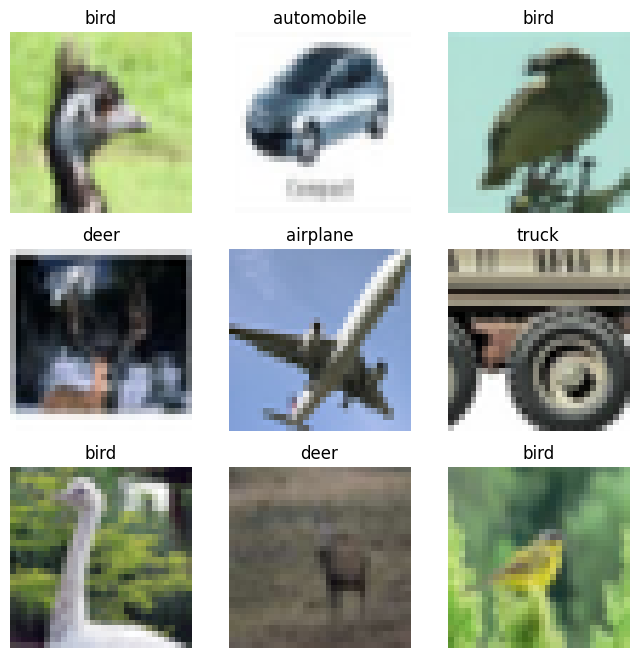

In [6]:
labels = {
    0: 'airplane', 1: 'automobile', 2: 'bird', 3: 'cat', 4: 'deer',
    5: 'dog', 6: 'frog', 7: 'horse', 8: 'ship', 9: 'truck'
}

pre = keras.utils.image_dataset_from_directory(
    '../datasets/cifar10/train', image_size=(32, 32), batch_size=9, shuffle=True, label_mode='int'
)

sample_images, sample_labels = next(iter(pre))

figure = plt.figure(figsize=(8, 8))
for i in range(9):
    img   = sample_images[i].numpy().astype(np.uint8)
    label = sample_labels[i].numpy()
    figure.add_subplot(3, 3, i + 1)
    plt.title(labels[label])
    plt.axis('off')
    plt.imshow(img)

plt.show()